### Reglas de formato y presentación
- El trabajo debe estar bien comentado (utilizando #) para que el código sea fácil de entender por sus compañeros y profesores.

- El mismo debe ser completado en este Jupyter Notebook y entregado como tal, es decir en un archivo .ipynb


# Big Data
## Trabajo Práctico 2

### Modalidad de entrega
- Al finalizar el trabajo práctico deben hacer un último <i>commit</i> en su repositorio de GitHub con el mensaje “Entrega final del tp”.
- Asegurense de haber creado una carpeta llamada TP2
- La última versión en el repositorio es la que será evaluada. Por lo que es importante que:
    - No hagan nuevos <i>push</i> despues de haber entregado su versión final. Esto generaría confusión acerca de que versión es la que quieren que se les corrija.

### Fecha de entrega:
Viernes 24 de octubre a las 23:59hs

### Parte A

#### Ejercicio 1
Usando la API de Yahoo Finance, obtener la serie de alguna acción. Pueden buscar cualquier acción de su interés.

In [7]:
import requests
from urllib.parse import quote_plus
symbol = "PLTR"
range = "5y"
interval = "1mo"
url = f" https://query1.finance.yahoo.com/v8/finance/chart/{symbol}?range={range}&interval={interval}"

## Queremos observar la evolución de la acción de Palantir durante los últimos 5 años, tomando el valor de la acción al cierre de cada mes.

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/141.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
}

## Se emplea el código ocupado en el módulo para obtener la serie de precios.

response = requests.request("GET", url, headers=headers)

print(response)

data = response.json()

data

<Response [200]>


{'chart': {'result': [{'meta': {'currency': 'USD',
     'symbol': 'PLTR',
     'exchangeName': 'NMS',
     'fullExchangeName': 'NasdaqGS',
     'instrumentType': 'EQUITY',
     'firstTradeDate': 1601472600,
     'regularMarketTime': 1760990400,
     'hasPrePostMarketData': True,
     'gmtoffset': -14400,
     'timezone': 'EDT',
     'exchangeTimezoneName': 'America/New_York',
     'regularMarketPrice': 181.59,
     'fiftyTwoWeekHigh': 190.0,
     'fiftyTwoWeekLow': 40.9,
     'regularMarketDayHigh': 183.09,
     'regularMarketDayLow': 177.44,
     'regularMarketVolume': 31850481,
     'longName': 'Palantir Technologies Inc.',
     'shortName': 'Palantir Technologies Inc.',
     'chartPreviousClose': 9.27,
     'priceHint': 2,
     'currentTradingPeriod': {'pre': {'timezone': 'EDT',
       'start': 1760947200,
       'end': 1760967000,
       'gmtoffset': -14400},
      'regular': {'timezone': 'EDT',
       'start': 1760967000,
       'end': 1760990400,
       'gmtoffset': -14400},
    

#### Ejercicio 2
Guarden los precios de los ítems obtenidos en un dataframe y calculen el precio promedio, el mínimo y el máximo.

In [18]:

chart = data["chart"]["result"][0]
timestamps = chart["timestamp"]
closes = chart["indicators"]["quote"][0]["close"]

import pandas as pd
from datetime import datetime

dates = [datetime.fromtimestamp(ts) for ts in timestamps]

df = pd.DataFrame({
    "Date": dates,
    "Close": closes
})

df.set_index("Date", inplace=True)

df

# Se sigue el procedimiento empleado en el video para armar el dataframe. A continuación se calcula precio máximo, mínimo y promedio para los últimos
# 5 años de Palantir. Seleccionamos close para que entregue columna de precio de cierre.

pmean = df['Close'].mean()
pmax = df['Close'].max()
pmin = df['Close'].min()

print(f"Precio Promedio: {pmean}")
print(f"Precio Máximo: {pmax}")
print(f"Precio Mínimo: {pmin}")




Precio Promedio: 41.5054099598869
Precio Máximo: 182.4199981689453
Precio Mínimo: 6.420000076293945


#### Ejercicio 3
Armen un histograma de los precios usando Matplotlib. ¿Ven algún <i>outlier<i>?

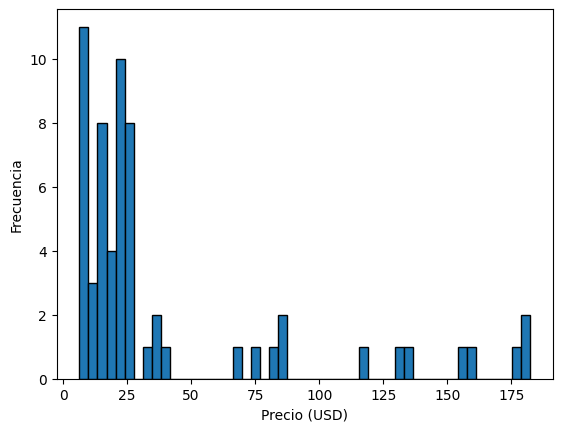

In [24]:
import matplotlib.pyplot as plt

plt.hist(df["Close"], bins=50, edgecolor='black')
plt.xlabel("Precio (USD)")
plt.ylabel("Frecuencia")
plt.show()
## Al crear un histograma, se observa una mayor repetición en los precios menores, lo cual tiene sentido considerando que el auge de Palantir se
## produjo recientemente y el precio de su acción se disparo a casi 200 dólares.


#### Ejercicio 4
Busquen una api que no se haya trabajado en clase y realicen un request. Puede ser cualquier api, por ejemplo hay una api climática llamada Open Meteo, Spotify, etc. Expliquen los pasos que siguen.

In [2]:
# Se busca realizar un request en la api del Financial Times
import requests
url_arg = "https://apis.datos.gob.ar/series/api/series?ids=168.1_T_CAMBIOR_D_0_0_26&format=json"
# Podemos pedir varios indicadores a la vez separando con comas

response = requests.get(url_arg) # En esta api no hace falta agregar headers
print(response)

datos = response.json()
datos

<Response [502]>


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

### Parte B

#### Ejercicio 5
De la página de noticias de [Infobae](https://www.infobae.com/), utilicen herramientas de web scraping para obtener los links de las noticias de la portada. Guarden los links obtenidos en un dataframe y expórtenlo a un archivo de excel.

Nota 1: es posible que logren obtener los links a las noticias sin el dominio: "https://www.infobae.com/". De ser así, concatenen el dominio a la ruta del link obtenido, tal que se obtenga un link al que se pueda acceder. Es decir, que las cadenas de caracteres finales tendrán la forma: https://www.infobae.com/*texto_obtenido*)

Nota 2: junto con su entrega, adjunten una captura de la página de noticias al momento de correr su código. Eso servirá al momento de la corrección para verificar que los links obtenidos hacen referencia a las noticias de ese día y hora.

In [22]:
# =========================================
# Web Scraping: Infobae (Home) -> Noticias
# =========================================

import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
from datetime import datetime
from urllib.parse import urljoin, urlsplit, urlunsplit

BASE_URL = "https://www.infobae.com"

# User-Agent realista ayuda a evitar bloqueos
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/141.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "es-AR,es;q=0.9,en;q=0.8",
}

def extract_date_from_url(url: str):
    """
    Extrae fecha con patrón /YYYY/MM/DD/ desde la URL.
    Devuelve 'YYYY-MM-DD' o None.
    """
    # Normalizamos primero (quitamos query y fragment)
    parts = urlsplit(url)
    clean_url = urlunsplit((parts.scheme, parts.netloc, parts.path, "", ""))
    m = re.search(r"/(\d{4})/(\d{2})/(\d{2})/", clean_url)
    if not m:
        return None
    y, mth, d = m.groups()
    try:
        return datetime(int(y), int(mth), int(d)).strftime("%Y-%m-%d")
    except ValueError:
        return None

def normalize_url(href: str) -> str:
    """
    Convierte href relativo en absoluto y limpia query/fragment.
    Solo devuelve URLs dentro de infobae.com
    """
    abs_url = urljoin(BASE_URL, href)
    parts = urlsplit(abs_url)
    # filtramos dominio
    if not parts.netloc.endswith("infobae.com"):
        return None
    # quitamos query y fragment
    return urlunsplit((parts.scheme, parts.netloc, parts.path, "", ""))

def extract_title(a_tag) -> str:
    """
    Obtiene un título razonable del <a>:
    1) texto visible del <a>
    2) atributo title
    3) aria-label
    4) texto de hijos comunes (h2/h3/span)
    """
    # 1) texto del link
    txt = a_tag.get_text(" ", strip=True)
    if txt:
        return txt
    # 2) title
    txt = a_tag.get("title")
    if txt and txt.strip():
        return txt.strip()
    # 3) aria-label
    txt = a_tag.get("aria-label")
    if txt and txt.strip():
        return txt.strip()
    # 4) hijos frecuentes
    for tagname in ("h2", "h3", "span"):
        child = a_tag.find(tagname)
        if child:
            txt = child.get_text(" ", strip=True)
            if txt:
                return txt
    return ""

# ---------- Descarga y parsing ----------
resp = requests.get(BASE_URL, headers=HEADERS, timeout=15)
resp.raise_for_status()
soup = BeautifulSoup(resp.content, "html.parser")

# ---------- Recolección ----------
links, titulos, fechas = [], [], []
vistos = set()

for a in soup.find_all("a", href=True):
    href = a.get("href")
    if not href:
        continue

    full_url = normalize_url(href)
    if not full_url:
        continue

    # Sólo notas con fecha en la URL (noticias reales)
    fecha = extract_date_from_url(full_url)
    if not fecha:
        continue

    if full_url in vistos:
        continue

    title = extract_title(a)
    # algunos enlaces de navegación traen textos vacíos
    if not title:
        continue

    links.append(full_url)
    titulos.append(title)
    fechas.append(fecha)
    vistos.add(full_url)

# ---------- DataFrame y limpieza ----------
df = pd.DataFrame({"Título": titulos, "Link": links, "Fecha": fechas})

# dedup por Link primero (mismo recurso), luego por Título
df = df.drop_duplicates(subset=["Link"], keep="first")
df = df.drop_duplicates(subset=["Título"], keep="first")

# ordenar por fecha desc
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
df = df.sort_values("Fecha", ascending=False).reset_index(drop=True)
df["Fecha"] = df["Fecha"].dt.strftime("%Y-%m-%d")

print(f"Se encontraron {len(df)} noticias únicas con fecha en la URL (Infobae Home).")
display(df.head(10)[["Título", "Fecha", "Link"]])

# ---------- Exportar a Excel ----------
stamp = datetime.now().strftime("%Y%m%d_%H%M")
outfile = f"noticias_infobae_{stamp}.xlsx"
df.to_excel(outfile, index=False, sheet_name="Noticias")
print(f"Archivo exportado: {outfile}")


Se encontraron 80 noticias únicas con fecha en la URL (Infobae Home).


,Título,Fecha,Link
0,Las razones por las que Estados Unidos sancion...,2025-10-24,https://www.infobae.com/colombia/2025/10/24/es...
1,“It: Bienvenidos a Derry”: horarios de estreno...,2025-10-24,https://www.infobae.com/entretenimiento/2025/1...
2,La Tierra pierde brillo: por qué este fenómeno...,2025-10-24,https://www.infobae.com/america/ciencia-americ...
3,3 señales claves que ayudan a identificar una ...,2025-10-24,https://www.infobae.com/tendencias/2025/10/24/...
4,Un estudio sugiere que la vitamina D ayuda a p...,2025-10-24,https://www.infobae.com/america/ciencia-americ...
5,Qué no decirle a una persona con TOC: claves p...,2025-10-24,https://www.infobae.com/salud/ciencia/2025/10/...
6,Los hijos de Britney Spears han vuelto a corta...,2025-10-24,https://www.infobae.com/entretenimiento/2025/1...
7,Bad Bunny gana el Premio Billboard Latino al M...,2025-10-24,https://www.infobae.com/entretenimiento/2025/1...
8,Keith Urban pidió a sus fans dejar de especula...,2025-10-24,https://www.infobae.com/entretenimiento/2025/1...
9,El Inter Miami de Lionel Messi comenzará su ca...,2025-10-24,https://www.infobae.com/deportes/2025/10/24/el...


Archivo exportado: noticias_infobae_20251024_2302.xlsx


#### Ejercicio 6
Realicen un análisis de sentimiento para los títulos de las noticias que encontraron. Reporten los 3 títulos más positivos y los 3 más negativos, junto con el valor obtenido.

In [14]:
!pip install vaderSentiment

In [23]:
import pandas as pd
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Cargar spaCy español
nlp = spacy.load("es_core_news_sm")
stopwords_spacy = spacy.lang.es.stop_words.STOP_WORDS
NEGATIONS = {"no","nunca","jamás","sin","ni"}

def limpiar_titulos_spacy(titulo: str) -> str:
    doc = nlp(titulo.lower())
    lemmas = []
    for w in doc:
        if (w.text not in stopwords_spacy or w.text in NEGATIONS) and not w.is_punct:
            # usa lemma_ si existe, si no, el texto
            lemmas.append(w.lemma_ if w.lemma_ else w.text)
    return " ".join(lemmas)

sia = SentimentIntensityAnalyzer()

df["titulo_limpio"] = df["Título"].apply(limpiar_titulos_spacy)
df["score"] = df["titulo_limpio"].apply(lambda x: sia.polarity_scores(x)["compound"])

top_3_positivos = df.nlargest(3, "score")[["Título", "score"]]
top_3_negativos = df.nsmallest(3, "score")[["Título", "score"]]

from IPython.display import display

# Ver un resumen rápido
print(f"Filas procesadas: {len(df)}")
print("Primeras filas (con título limpio y score):")
display(df[["Título", "titulo_limpio", "score"]].head(10))

# Top 3 positivos y negativos
top_3_positivos = df.nlargest(3, 'score')[['Título', 'score']]
top_3_negativos = df.nsmallest(3, 'score')[['Título', 'score']]

print("\n" + "=" * 50)
print("LOS 3 MÁS POSITIVOS:")
print("=" * 50)
print(top_3_positivos.to_string(index=False))

print("\n" + "=" * 50)
print("LOS 3 MÁS NEGATIVOS:")
print("=" * 50)
print(top_3_negativos.to_string(index=False))


Filas procesadas: 80
Primeras filas (con título limpio y score):


,Título,titulo_limpio,score
0,Las razones por las que Estados Unidos sancion...,razón unidos sancionar gustavo petro trump tom...,0.0000
1,“It: Bienvenidos a Derry”: horarios de estreno...,itir bienvenido derry horario estreno tráiler ...,0.0000
2,La Tierra pierde brillo: por qué este fenómeno...,tierra perder brillo fenómeno riesgo equilibri...,0.0000
3,3 señales claves que ayudan a identificar una ...,3 señal clave ayudar identificar relación basa...,0.0000
4,Un estudio sugiere que la vitamina D ayuda a p...,estudio sugerir vitamina d ayuda proteger adn ...,0.0000
5,Qué no decirle a una persona con TOC: claves p...,no decir él persona toc clave brindar apoyo ef...,-0.2960
6,Los hijos de Britney Spears han vuelto a corta...,hijo britney spears volver cortar contacto afi...,0.0000
7,Bad Bunny gana el Premio Billboard Latino al M...,bad bunny ganar premio billboard latino artist...,-0.5423
8,Keith Urban pidió a sus fans dejar de especula...,keith urr pedir fan dejar especular cambio let...,0.3182
9,El Inter Miami de Lionel Messi comenzará su ca...,inter miami lionel messi comenzar camino playo...,0.0000



LOS 3 MÁS POSITIVOS:
                                                                                                                                                    Título  score
                                                     Maduro intentó enviar una súplica a Trump en inglés durante un acto en TV: “Not crazy war, yes peace” 0.7524
                                      Retiran del mercado más de 140.000 frascos de un popular medicamento para el colesterol Por Maricielo Grados Córdova 0.4215
Keith Urban pidió a sus fans dejar de especular sobre los cambios en las letras de sus canciones tras el divorcio con Nicole Kidman Por Evelin Meza Capcha 0.3182

LOS 3 MÁS NEGATIVOS:
                                                                                                                                  Título   score
                                Sin tregua: un bombardeo de Putin dejó dos muertos en Kherson y un dron ucraniano estalló cerca de Moscú -0.5574
Más allá de Star W

In [15]:
!pip install stop-words

In [17]:
import spacy.cli

spacy.cli.download("es_core_news_sm")

✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
